CLASE 3
---
Claudio Alejo Encarnación Martínez (750597)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_csv('/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/Advertising.csv')
df.head(15)

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


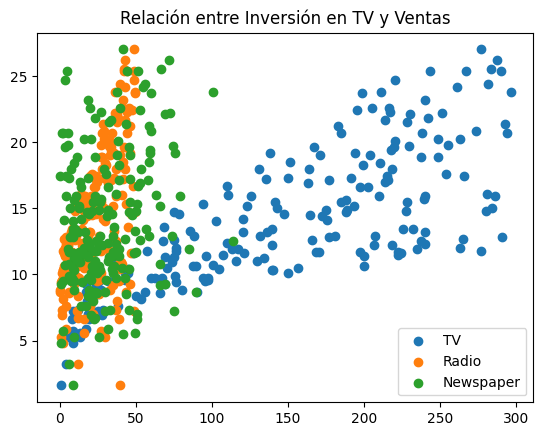

In [13]:
plt.scatter(df['TV'], df['sales'])
plt.scatter(df['radio'], df['sales'])
plt.scatter(df['newspaper'], df['sales'])
plt.title('Relación entre Inversión en TV y Ventas')
plt.legend(['TV', 'Radio', 'Newspaper'])
plt.show()

In [21]:
Xv = np.reshape(df['TV'].values, [-1, 1])

In [22]:
X = Xv
X

array([[230.1],
       [ 44.5],
       [ 17.2],
       [151.5],
       [180.8],
       [  8.7],
       [ 57.5],
       [120.2],
       [  8.6],
       [199.8],
       [ 66.1],
       [214.7],
       [ 23.8],
       [ 97.5],
       [204.1],
       [195.4],
       [ 67.8],
       [281.4],
       [ 69.2],
       [147.3],
       [218.4],
       [237.4],
       [ 13.2],
       [228.3],
       [ 62.3],
       [262.9],
       [142.9],
       [240.1],
       [248.8],
       [ 70.6],
       [292.9],
       [112.9],
       [ 97.2],
       [265.6],
       [ 95.7],
       [290.7],
       [266.9],
       [ 74.7],
       [ 43.1],
       [228. ],
       [202.5],
       [177. ],
       [293.6],
       [206.9],
       [ 25.1],
       [175.1],
       [ 89.7],
       [239.9],
       [227.2],
       [ 66.9],
       [199.8],
       [100.4],
       [216.4],
       [182.6],
       [262.7],
       [198.9],
       [  7.3],
       [136.2],
       [210.8],
       [210.7],
       [ 53.5],
       [261.3],
       [

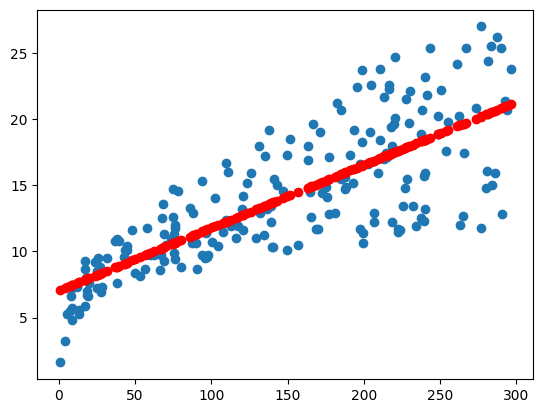

In [27]:
lr = LinearRegression()
lr.fit(X, df['sales'])

plt.scatter(df['TV'], df['sales'])
plt.scatter(df['TV'], lr.predict(X), color='red')

In [75]:
#Beta cero
b0=lr.intercept_
print("El valor de beta cero es:",b0)

El valor de beta cero es: 7.032593549127694


In [76]:
#Beta uno
b1=lr.coef_
print("El valor de beta uno es:",b1)

El valor de beta uno es: [0.04753664]


Calculando los intervalos
---

In [ ]:
#Calcular error estandar de beta uno
X_barra=np.mean(df['TV'])
Suma_diferencia_cuadrada=df['TV'] - X_barra
Suma_diferencia_cuadrada = Suma_diferencia_cuadrada**2
Suma_diferencia_cuadrada =np.sum(Suma_diferencia_cuadrada)

E=df['sales'] - lr.predict(X)
E=E**2
RSS=np.sum(E)
sigma2=RSS/(200-2)
sigma2

SE_b0=np.sqrt(sigma2*((1/200) + (X_barra**2)/Suma_diferencia_cuadrada))
SE_b0

np.float64(0.45784294027347855)

In [74]:
#Calcular error estandar de beta uno
SE_b1 = np.sqrt(sigma2/Suma_diferencia_cuadrada)
SE_b1

np.float64(0.0026906071877968707)

Valores que me tienen que dar
SE(beta0)=0.4578
SE(beta1)=0.027

Para intervalos:
Sumar valor de beta +/- 2SE(betai)

In [79]:
#INTERVALOS DE CONFIANZA
print("Intervalo de confianza para beta cero:", b0 - 2*SE_b0,",", b0 + 2*SE_b0)
print("Intervalo de confianza para beta uno:", b1 - 2*SE_b1,",", b1 + 2*SE_b1)

Intervalo de confianza para beta cero: 6.116907668580737 , 7.948279429674651
Intervalo de confianza para beta uno: [0.04215543] , [0.05291785]


PRUEBA DE HIPÓTESIS
---

Ho: No hay relación entre TV y sales
Hi: Bi =/ 0


In [81]:
from scipy import stats
t_b1=b1/SE_b1
p_b1=2*(1-stats.t.cdf(np.abs(t_b1), 198))
p_b1

array([0.])

In [82]:
t_b0=b0/SE_b0
p_b0=2*(1-stats.t.cdf(np.abs(t_b0), 198))
p_b0

np.float64(0.0)

Como el p-value es menor a 0.05 (por nivel de significancia escogido), podemos concluir con un 95% de confianza que NOOO es coincidencia